# 09. Multi-Agent RL: Independent Q-Learning w grze koordynacyjnej

Dwóch agentów uczy się równocześnie w powtarzanej grze koordynacyjnej. Każdy widzi własną funkcję Q i traktuje drugiego jako część zmieniającego się środowiska.

**Założenie organizacyjne:** notebook działa lokalnie i nie wymaga internetu.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Wypłata wspólna: najlepiej skoordynować się na akcji 1, ale akcja 0 też jest lokalnie stabilna.
R = np.array([[3, 0],
              [0, 5]], dtype=float)

def train(seed=0, episodes=5000, alpha=0.08, eps0=0.4, eps_end=0.02):
    rng=np.random.default_rng(seed)
    Q1=np.zeros(2); Q2=np.zeros(2)
    actions=[]; rewards=[]
    for ep in range(episodes):
        eps = eps_end + (eps0-eps_end)*np.exp(-ep/1200)
        a1 = int(rng.integers(2)) if rng.random()<eps else int(np.argmax(Q1 + rng.normal(0,1e-9,2)))
        a2 = int(rng.integers(2)) if rng.random()<eps else int(np.argmax(Q2 + rng.normal(0,1e-9,2)))
        r = R[a1,a2]
        Q1[a1] += alpha*(r-Q1[a1])
        Q2[a2] += alpha*(r-Q2[a2])
        actions.append((a1,a2)); rewards.append(r)
    return np.array(actions), np.array(rewards), Q1,Q2

actions,rewards,Q1,Q2 = train(seed=3)
print('Q1=',Q1.round(2),'Q2=',Q2.round(2))
print('Średnia nagroda w ostatnich 500 epizodach:', rewards[-500:].mean().round(3))

Q1= [3.   0.01] Q2= [2.99 0.  ]
Średnia nagroda w ostatnich 500 epizodach: 2.916


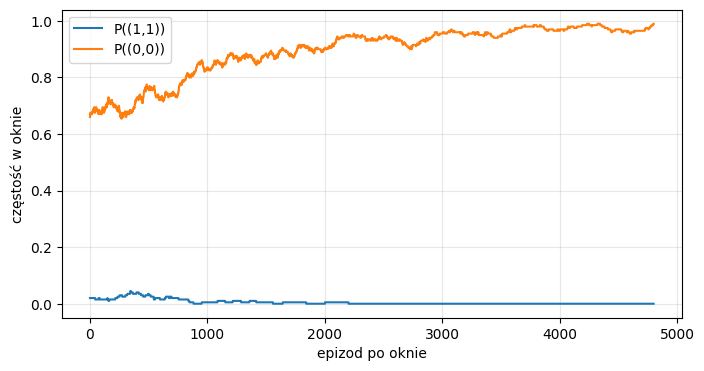

In [2]:
window=200
coord1=[]; coord0=[]
for i in range(window, len(actions)+1):
    w=actions[i-window:i]
    coord1.append(np.mean((w[:,0]==1)&(w[:,1]==1)))
    coord0.append(np.mean((w[:,0]==0)&(w[:,1]==0)))

plt.figure(figsize=(8,4))
plt.plot(coord1,label='P((1,1))')
plt.plot(coord0,label='P((0,0))')
plt.xlabel('epizod po oknie')
plt.ylabel('częstość w oknie')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [3]:
# Wiele ziaren pokaże, że uczenie może osiąść w różnych równowagach.
for seed in range(8):
    a,r,q1,q2=train(seed=seed,episodes=3500)
    last=a[-500:]
    p11=np.mean((last[:,0]==1)&(last[:,1]==1))
    p00=np.mean((last[:,0]==0)&(last[:,1]==0))
    print(seed, 'P11=',round(p11,2),'P00=',round(p00,2),'reward=',round(r[-500:].mean(),2))

0 P11= 0.96 P00= 0.0 reward= 4.8
1 P11= 0.0 P00= 0.94 reward= 2.83
2 P11= 0.0 P00= 0.96 reward= 2.88
3 P11= 0.0 P00= 0.96 reward= 2.87
4 P11= 0.94 P00= 0.0 reward= 4.7
5 P11= 0.95 P00= 0.0 reward= 4.74
6 P11= 0.0 P00= 0.95 reward= 2.86
7 P11= 0.0 P00= 0.96 reward= 2.87


## Zadanie
Zmień macierz nagród tak, aby jedna równowaga była **bezpieczna**, a druga **ryzykowna, lecz bardziej opłacalna**. Uruchom kilka ziaren losowych.

**Drugie dno:** w MARL problemem nie jest tylko estymacja wartości. Drugi agent jednocześnie zmienia swoją politykę, więc dane uczące przestają pochodzić ze stacjonarnego środowiska.